# Analysis of Wordle Datasets

The following analysis performs an exploratory data analysis on the Wordle corpus. The analysis will focus on identifying patterns that will be relevant to the development of the solvers.

### Explanation of Data

We have 3 wordlists `answer_list.txt`, `complete_list.txt` and `non_answer_list.txt`:

1. `complete_list.txt` - contains ALL possible words that are allowed to be guessed (14,855 words)

2. `answer_list.txt` - contains words that could show up as a solution. (2309 words) This list was originally 2315 words as set by the creator of the game but since being aquired by NYT they removed 6 words (AGORA PUPAL SLAVE LYNCH WENCH FIBRE). There has been 7 solutions that weren't on this list (GUANO SNAFU BALSA KAZOO LASER PIOUS BEAUT)

3. `non_answer_list.txt` - contains the words that are in the complete_list minus the answer_list (12,546 words)

### Loading the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_word_list(file_path, uppercase=True):
    with open(file_path, 'r') as file:
        words = [line.strip() for line in file.readlines()]
        if uppercase:
            words = [word.upper() for word in words]
    return pd.DataFrame(words, columns=['word'])

In [3]:
# load datasets
complete_list = load_word_list('../data/wordle_lists/complete_list.txt')
answer_list = load_word_list('../data/wordle_lists/answer_list.txt')
non_answer_list = load_word_list('../data/wordle_lists/non_answer_list.txt')

# show first 5 entries of complete_list
print(complete_list.head(), '\n', complete_list.shape)
print(answer_list.head(), '\n', answer_list.shape)
print(non_answer_list.head(), '\n', non_answer_list.shape)

    word
0  AAHED
1  AALII
2  AAPAS
3  AARGH
4  AARTI 
 (14855, 1)
    word
0  ABACK
1  ABASE
2  ABATE
3  ABBEY
4  ABBOT 
 (2309, 1)
    word
0  AAHED
1  AALII
2  AAPAS
3  AARGH
4  AARTI 
 (12546, 1)


In [4]:
def split(df):
    letters = ['letter_1', 'letter_2', 'letter_3', 'letter_4', 'letter_5']
    for i in range(5):
        df[letters[i]] = df['word'].str[i]
    return df

complete_list = split(complete_list)
answer_list = split(answer_list)
non_answer_list = split(non_answer_list)
complete_list.head()

,word,letter_1,letter_2,letter_3,letter_4,letter_5
0,AAHED,A,A,H,E,D
1,AALII,A,A,L,I,I
2,AAPAS,A,A,P,A,S
3,AARGH,A,A,R,G,H
4,AARTI,A,A,R,T,I


### What are the most common letters?

In [5]:
complete_list_letter_counts = complete_list[['letter_1', 'letter_2', 'letter_3', 'letter_4', 'letter_5']].apply(pd.Series.value_counts)
complete_list_letter_counts['sum'] = complete_list_letter_counts.sum(axis=1)
complete_list_letter_counts

,letter_1,letter_2,letter_3,letter_4,letter_5,sum
A,868,2682,1374,1319,885,7128
B,1003,108,386,282,70,1849
C,970,207,467,456,146,2246
D,735,108,467,551,874,2735
E,330,1857,998,2531,1739,7455
F,646,37,204,258,95,1240
G,685,94,427,487,171,1864
H,532,604,146,283,428,1993
I,180,1598,1173,1048,382,4381
J,225,13,59,42,3,342


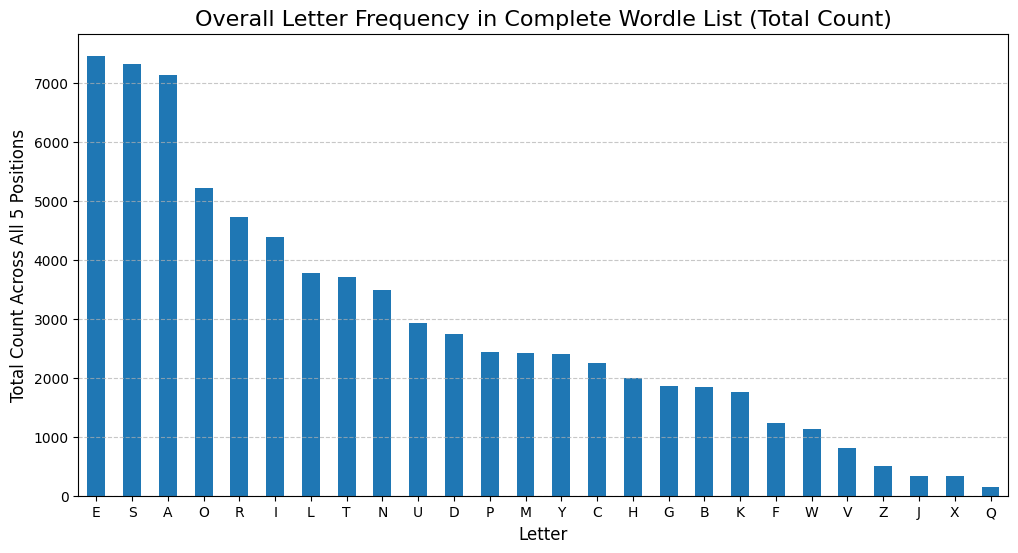

In [6]:
# sort descending by total sum
plot_data = complete_list_letter_counts['sum'].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plot_data.plot(kind='bar')
plt.title('Overall Letter Frequency in Complete Wordle List (Total Count)', fontsize=16)
plt.xlabel('Letter', fontsize=12)
plt.ylabel('Total Count Across All 5 Positions', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

### What are the most common letters in each position?

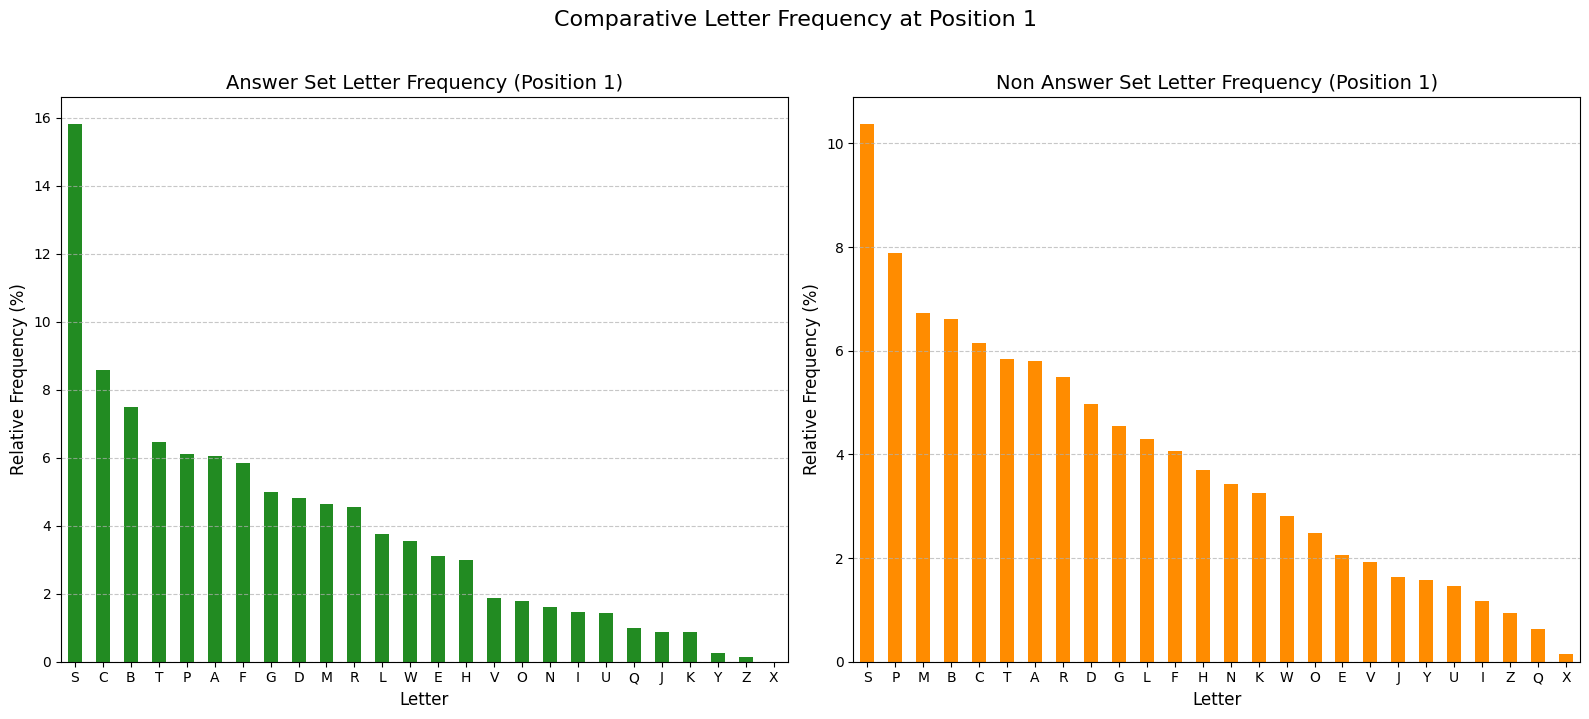

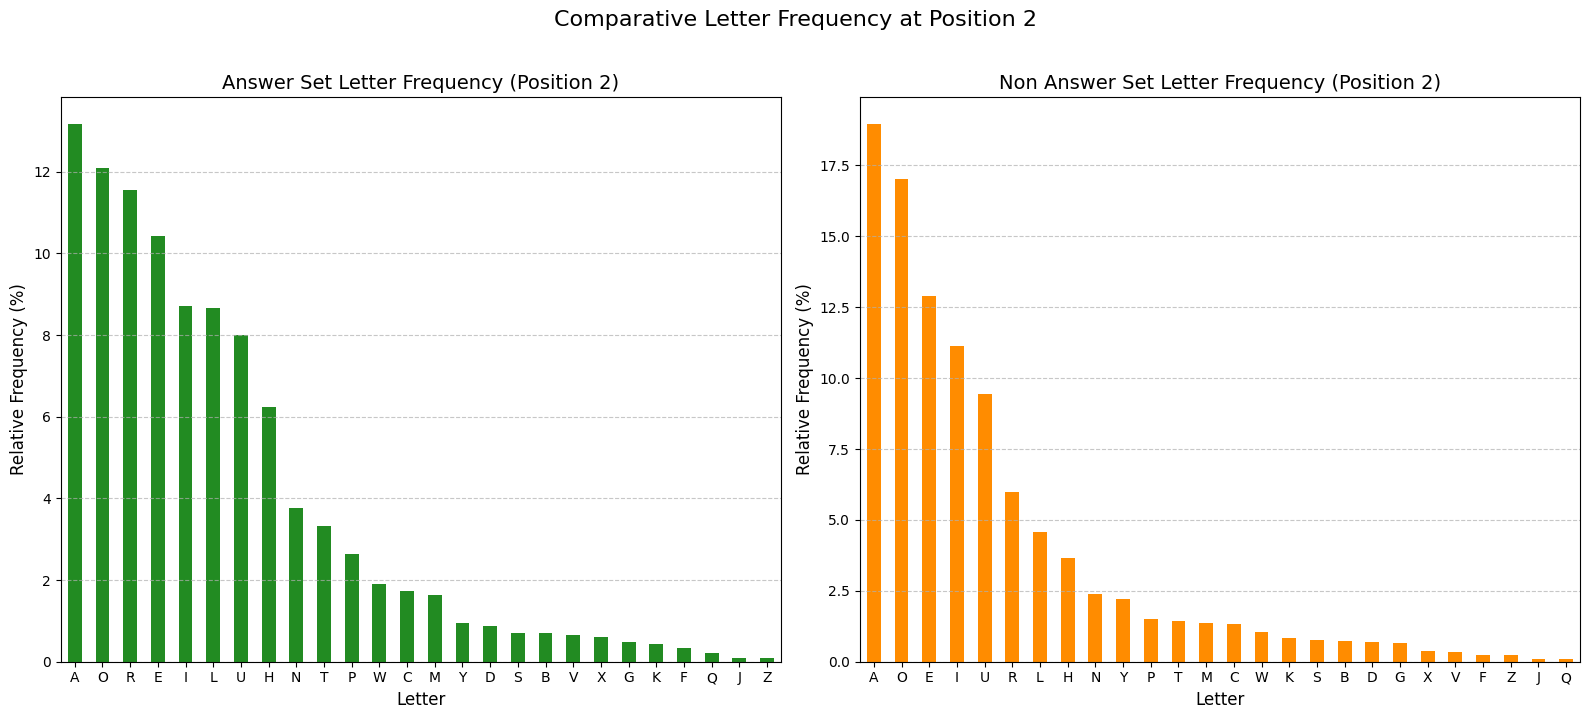

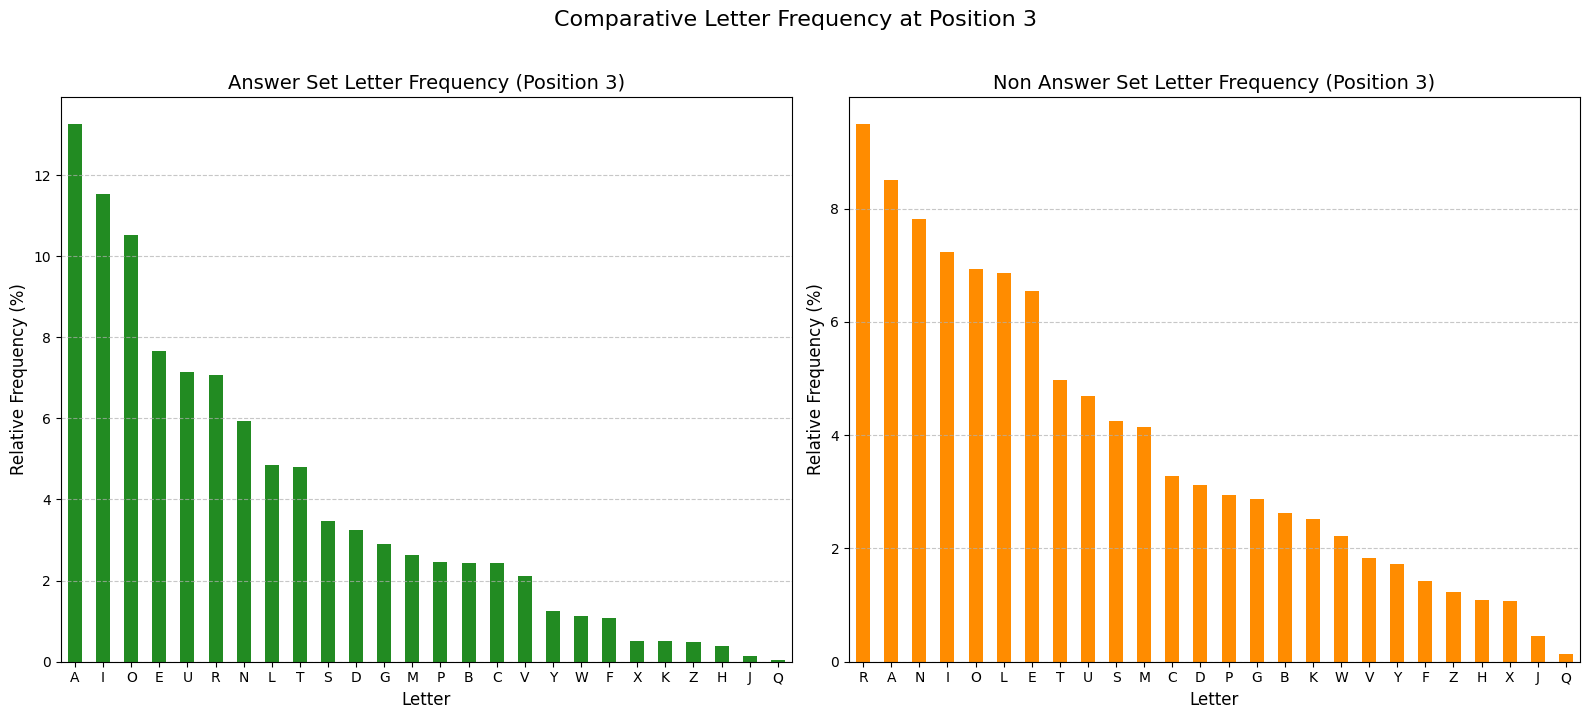

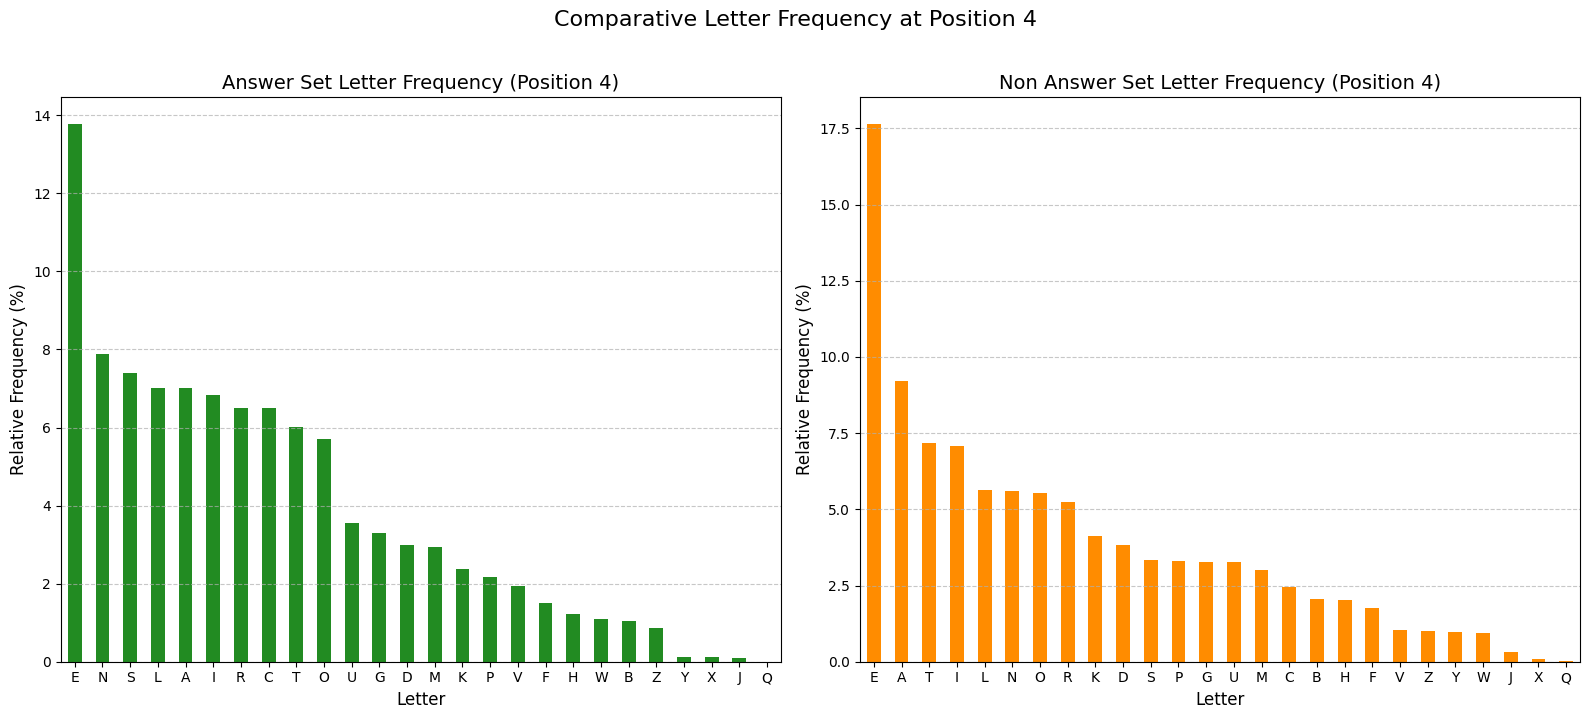

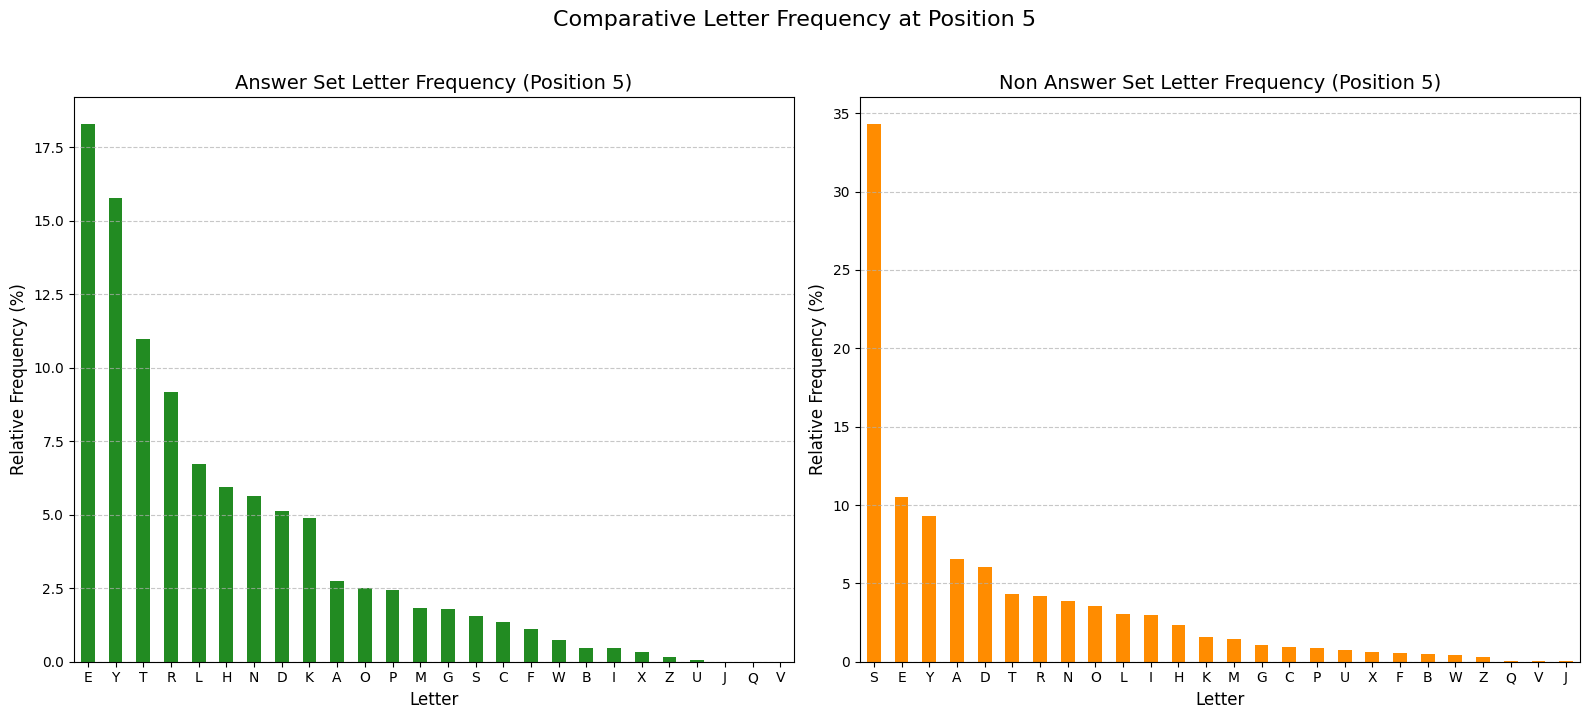

In [7]:
def plot_side_by_side_letter_frequency(answer_df, non_answer_df, position):
    # calculate and sort relative frequencies
    # multiply by 100 for percentage
    answer_freq = (answer_df[position].value_counts(normalize=True) * 100).sort_values(ascending=False)
    non_answer_freq = (non_answer_df[position].value_counts(normalize=True) * 100).sort_values(ascending=False)

    # make sure all letters are included with 0 for missing letters
    all_letters = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    answer_freq = answer_freq.reindex(all_letters, fill_value=0).sort_values(ascending=False)
    non_answer_freq = non_answer_freq.reindex(all_letters, fill_value=0).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    position_num = position.replace('letter_', '')

    # answer list plot
    answer_freq.plot(kind='bar', ax=axes[0], color='forestgreen')
    axes[0].set_title(f'Answer Set Letter Frequency (Position {position_num})', fontsize=14)
    axes[0].set_xlabel('Letter', fontsize=12)
    axes[0].set_ylabel('Relative Frequency (%)', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # non answer list plot
    non_answer_freq.plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title(f'Non Answer Set Letter Frequency (Position {position_num})', fontsize=14)
    axes[1].set_xlabel('Letter', fontsize=12)
    axes[1].set_ylabel('Relative Frequency (%)', fontsize=12)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle(f'Comparative Letter Frequency at Position {position_num}', fontsize=16, y=1.02)
    plt.tight_layout()


for position in ['letter_1', 'letter_2', 'letter_3', 'letter_4', 'letter_5']:
    plot_side_by_side_letter_frequency(answer_list, non_answer_list, position)

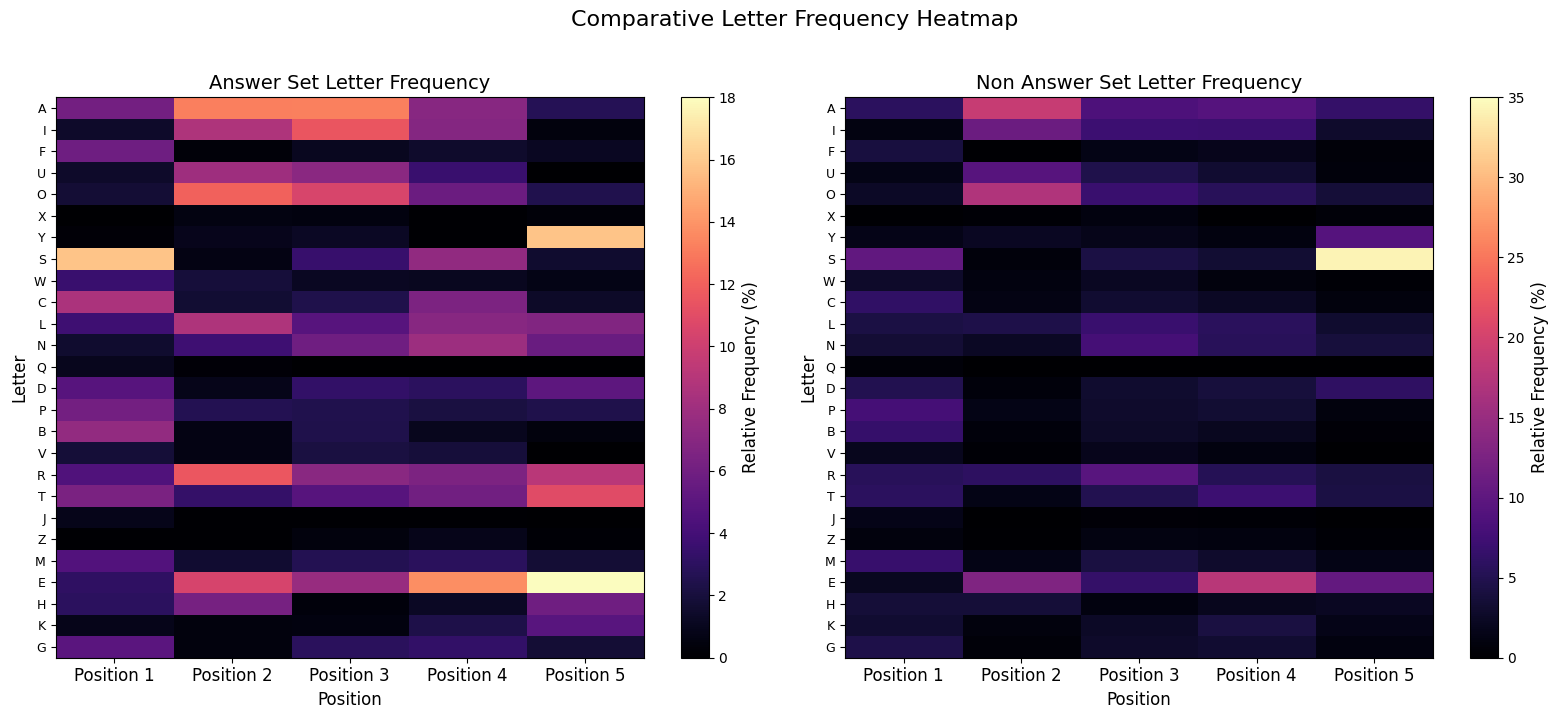

In [8]:
letters = set('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
positions = ['letter_1', 'letter_2', 'letter_3', 'letter_4', 'letter_5']
answer_matrix = np.zeros((len(letters), 5))
non_answer_matrix = np.zeros((len(letters), 5))

# build matrices
for i, position in enumerate(positions):
    answer_freq = (answer_list[position].value_counts(normalize=True) * 100)
    non_answer_freq = (non_answer_list[position].value_counts(normalize=True) * 100)
    for j, letter in enumerate(letters):
        answer_matrix[j, i] = answer_freq.get(letter, 0)
        non_answer_matrix[j, i] = non_answer_freq.get(letter, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# answer set heatmap
im1 = axes[0].imshow(answer_matrix, aspect='auto', cmap='magma', vmin=0, vmax=18)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['Position 1', 'Position 2', 'Position 3', 'Position 4', 'Position 5'], fontsize=12)
axes[0].set_yticks(range(len(letters)))
axes[0].set_yticklabels(list(letters), fontsize=9)
axes[0].set_xlabel('Position', fontsize=12)
axes[0].set_ylabel('Letter', fontsize=12)
axes[0].set_title('Answer Set Letter Frequency', fontsize=14)
cbar1 = plt.colorbar(im1)
cbar1.set_label('Relative Frequency (%)', fontsize=12)

# non answer set heatmap
im2 = axes[1].imshow(non_answer_matrix, aspect='auto', cmap='magma', vmin=0, vmax=35)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(['Position 1', 'Position 2', 'Position 3', 'Position 4', 'Position 5'], fontsize=12)
axes[1].set_yticks(range(len(letters)))
axes[1].set_yticklabels(list(letters), fontsize=9)
axes[1].set_xlabel('Position', fontsize=12)
axes[1].set_ylabel('Letter', fontsize=12)
axes[1].set_title('Non Answer Set Letter Frequency', fontsize=14)
cbar2 = plt.colorbar(im2)
cbar2.set_label('Relative Frequency (%)', fontsize=12)

plt.suptitle('Comparative Letter Frequency Heatmap', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### How are vowels distributed?

In [9]:
vowels = set('AEIOU')

answer_list['vowel_count'] = answer_list['word'].apply(lambda x: sum(1 for letter in x if letter in vowels))
non_answer_list['vowel_count'] = non_answer_list['word'].apply(lambda x: sum(1 for letter in x if letter in vowels))

print(f'The average number of vowels in answer list words: {answer_list["vowel_count"].mean():.2f}')
print(f'The average number of vowels in non answer list words: {non_answer_list["vowel_count"].mean():.2f}')

The average number of vowels in answer list words: 1.77
The average number of vowels in non answer list words: 1.83


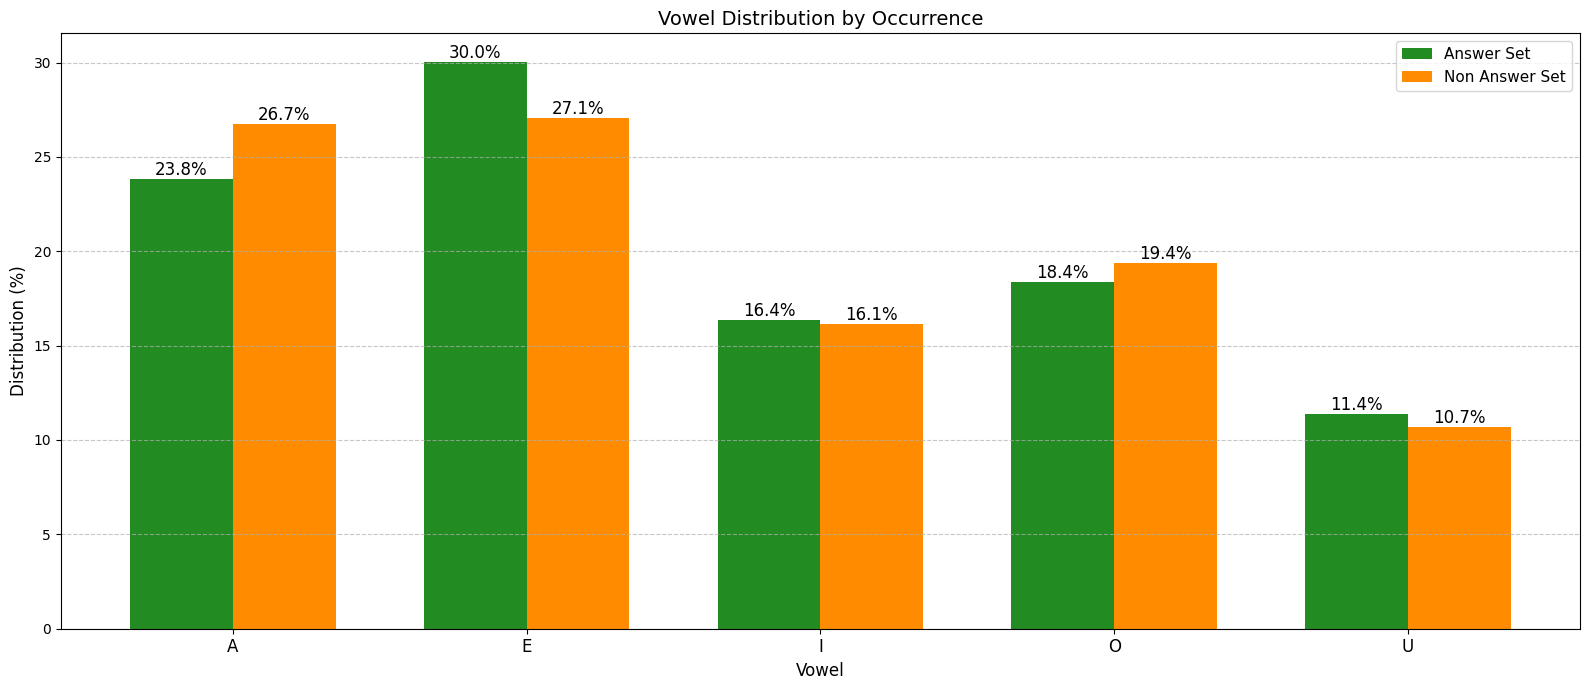

In [10]:
vowels = ['A', 'E', 'I', 'O', 'U']

def vowel_distribution_by_occurrence(df):
    counts = {v: df['word'].str.count(v).sum() for v in vowels}
    total = sum(counts.values())
    return pd.Series([(counts[v] / total) *100 for v in vowels], index=vowels)

answer_dist = vowel_distribution_by_occurrence(answer_list)
non_answer_dist = vowel_distribution_by_occurrence(non_answer_list)

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(vowels))
width = 0.35

bars1 = ax.bar(x - width/2, answer_dist, width, label='Answer Set', color='forestgreen')
bars2 = ax.bar(x + width/2, non_answer_dist, width, label='Non Answer Set', color='darkorange')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=12)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=12)

ax.set_xlabel('Vowel', fontsize=12)
ax.set_ylabel('Distribution (%)', fontsize=12)
ax.set_title('Vowel Distribution by Occurrence', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(vowels, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### How many words have duplicate letters?

In [11]:
answer_list_dupe_count = answer_list['word'].apply(lambda x: len(set(x)) < 5).sum()
non_answer_list_dupe_count = non_answer_list['word'].apply(lambda x: len(set(x)) < 5).sum()

print(f'Number of words with duplicate letters in answer list: {answer_list_dupe_count} out of {len(answer_list)} ({answer_list_dupe_count/len(answer_list)*100:.2f}%)')
print(f'Number of words with duplicate letters in non answer list: {non_answer_list_dupe_count} out of {len(non_answer_list)} ({non_answer_list_dupe_count/len(non_answer_list)*100:.2f}%)')

Number of words with duplicate letters in answer list: 747 out of 2309 (32.35%)
Number of words with duplicate letters in non answer list: 4743 out of 12546 (37.80%)
